# BANCO DE PREÇOS EM SAÚDE — 2020 A 2026

**Mini-Projeto Avaliativo · Módulo 2 · Semana 07**
Visualização de Dados e Business Intelligence

**Aluna:** Anaysa Pereira Lopes

---

| Seção | Sprint | Camada |
|-------|--------|--------|
| BASES | 1 — download dos sete anos | `raw` |
| DIAGNÓSTICO | 1 — mapeamento de discrepâncias | — |
| TRATAMENTO | 2 — encoding, tipos, nulos, duplicados | `staging` |
| CONCATENAÇÃO | 2 — append dos sete anos | `curated` |
| KPIS | 3 — indicadores e validação das fórmulas | — |
| ANÁLISES | 5 — interpretação dos resultados | — |

Fonte: [Banco de Preços em Saúde](https://dadosabertos.saude.gov.br/dataset/bps) —
Ministério da Saúde.

# IMPORTS

In [1]:
import io
import re
import zipfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

VERDE_ESCURO, VERDE_MEDIO = "#1B5E4A", "#2E8B6F"
AZUL, AMBAR, VERMELHO = "#1F4E79", "#E8A33D", "#C0392B"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# PARÂMETROS

In [2]:
ALUNA = "AnaysaPereiraLopes"
ANOS = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

DIR_RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DIR_RAW = DIR_RAIZ / "dados" / "raw"
DIR_STAGING = DIR_RAIZ / "dados" / "staging"
DIR_CURATED = DIR_RAIZ / "dados" / "curated"
DIR_RELATORIOS = DIR_RAIZ / "relatorios"
DIR_DOCS = DIR_RAIZ / "docs"

for d in (DIR_RAW, DIR_STAGING, DIR_CURATED, DIR_RELATORIOS, DIR_DOCS):
    d.mkdir(parents=True, exist_ok=True)

ARQUIVO_CURATED = DIR_CURATED / f"BPS_20_26_{ALUNA}.csv"
ARQUIVO_CURATED_GZ = DIR_CURATED / f"BPS_20_26_{ALUNA}.csv.gz"

print("Raiz do projeto:", DIR_RAIZ)

Raiz do projeto: d:\SENAI\Análise de Dados\ Mini-Projeto-M2S06\projeto-bps-m2s07


In [3]:
class Registro:
    """Acumula o log de uma etapa e grava em /relatorios."""

    def __init__(self):
        self.linhas = []

    def p(self, texto=""):
        print(texto)
        self.linhas.append(str(texto))

    def salvar(self, caminho):
        Path(caminho).write_text("\n".join(self.linhas), encoding="utf-8")
        print(f"\n>>> {Path(caminho).name}")


def moeda(v):
    """Formata em BRL."""
    return "R$ " + f"{v:,.2f}".replace(",", "@").replace(".", ",").replace("@", ".")


def numero(v, casas=0):
    """Formata com separador de milhar pt-BR."""
    return f"{v:,.{casas}f}".replace(",", "@").replace(".", ",").replace("@", ".")

# BASES

## SPRINT 1 — DOWNLOAD DOS SETE ANOS

O portal distribui cada ano como `.zip`, não como `.csv`. Dentro de cada um há um
único CSV nomeado pelo ano. A URL segue padrão fixo, o que permite automatizar:

```
https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/BPS/csv/<ANO>_csv.zip
```

In [4]:
URL_BASE = "https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/BPS/csv/{ano}_csv.zip"
URL_DICIONARIO = "https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/BPS/Metadados_BPS_07_04_2026.pdf"


def baixar(url, destino):
    """Baixa o arquivo se ainda não existir localmente."""
    if destino.exists() and destino.stat().st_size > 0:
        print(f"  [PULADO]   {destino.name} ({destino.stat().st_size / 1024**2:.2f} MB)")
        return destino
    print(f"  [BAIXANDO] {destino.name}")
    urllib.request.urlretrieve(url, destino)
    print(f"  [OK]       {destino.name} ({destino.stat().st_size / 1024**2:.2f} MB)")
    return destino


def extrair(caminho_zip, pasta_destino):
    """Extrai o CSV do ZIP anual."""
    with zipfile.ZipFile(caminho_zip) as zf:
        nomes = zf.namelist()
        zf.extractall(pasta_destino)
    return [pasta_destino / n for n in nomes]

In [5]:
print("=" * 74)
print("DOWNLOAD DAS BASES ANUAIS (CAMADA RAW)")
print("=" * 74)

inventario = []

for ano in ANOS:
    print(f"\n--- {ano} ---")
    caminho_zip = baixar(URL_BASE.format(ano=ano), DIR_RAW / f"{ano}_csv.zip")
    for csv in extrair(caminho_zip, DIR_RAW):
        mb = csv.stat().st_size / 1024**2
        print(f"  [EXTRAÍDO] {csv.name} ({mb:.2f} MB)")
        inventario.append({"ano": ano, "arquivo": csv.name, "tamanho_mb": round(mb, 2)})

print("\n--- dicionário oficial ---")
baixar(URL_DICIONARIO, DIR_DOCS / "Metadados_BPS_07_04_2026.pdf")

pd.DataFrame(inventario)

DOWNLOAD DAS BASES ANUAIS (CAMADA RAW)

--- 2020 ---
  [PULADO]   2020_csv.zip (6.88 MB)
  [EXTRAÍDO] 2020.csv (50.07 MB)

--- 2021 ---
  [PULADO]   2021_csv.zip (7.03 MB)
  [EXTRAÍDO] 2021.csv (50.42 MB)

--- 2022 ---
  [PULADO]   2022_csv.zip (7.59 MB)
  [EXTRAÍDO] 2022.csv (53.22 MB)

--- 2023 ---
  [PULADO]   2023_csv.zip (2.99 MB)
  [EXTRAÍDO] 2023.csv (20.79 MB)

--- 2024 ---
  [PULADO]   2024_csv.zip (2.74 MB)
  [EXTRAÍDO] 2024.csv (17.83 MB)

--- 2025 ---
  [PULADO]   2025_csv.zip (3.51 MB)
  [EXTRAÍDO] 2025.csv (22.03 MB)

--- 2026 ---
  [PULADO]   2026_csv.zip (1.09 MB)
  [EXTRAÍDO] 2026.csv (7.47 MB)

--- dicionário oficial ---
  [PULADO]   Metadados_BPS_07_04_2026.pdf (0.42 MB)


,ano,arquivo,tamanho_mb
0,2020,2020.csv,50.07
1,2021,2021.csv,50.42
2,2022,2022.csv,53.22
3,2023,2023.csv,20.79
4,2024,2024.csv,17.83
5,2025,2025.csv,22.03
6,2026,2026.csv,7.47


# DIAGNÓSTICO

## SPRINT 1 — MAPEAMENTO DE DISCREPÂNCIAS ENTRE OS ANOS


In [6]:
PADRAO_MOJIBAKE = re.compile("[\u00c3\u00c2][\u0080-\u00ff]")


def ler_ano_raw(ano):
    """Lê o CSV anual da camada raw. dtype=str preserva zeros à esquerda dos CNPJ."""
    with zipfile.ZipFile(DIR_RAW / f"{ano}_csv.zip") as zf:
        conteudo = zf.read(zf.namelist()[0])
    df = pd.read_csv(
        io.StringIO(conteudo.decode("utf-8")),
        sep=";", dtype=str, keep_default_na=False, na_values=[""], low_memory=False,
    )
    return df, conteudo


def detectar_encoding(dados_bytes):
    """Retorna o primeiro encoding que decodifica o arquivo inteiro."""
    for enc in ("utf-8", "cp1252", "latin-1"):
        try:
            dados_bytes.decode(enc)
            return enc
        except UnicodeDecodeError:
            continue
    return "desconhecido"

In [7]:
rel_diag = Registro()

rel_diag.p("=" * 74)
rel_diag.p("SPRINT 1 - MAPEAMENTO DE DISCREPÂNCIAS ENTRE AS BASES ANUAIS DO BPS")
rel_diag.p("Aluna: Anaysa Pereira Lopes")
rel_diag.p("=" * 74)
rel_diag.p("\n\n1. INVENTÁRIO E ENCODING")
rel_diag.p("-" * 74)

bases_raw, colunas_por_ano = {}, {}

for ano in ANOS:
    df_ano, bruto = ler_ano_raw(ano)
    encoding = detectar_encoding(bruto)
    mojibake = len(PADRAO_MOJIBAKE.findall(bruto.decode(encoding, errors="replace")))

    bases_raw[ano] = df_ano
    colunas_por_ano[ano] = list(df_ano.columns)

    rel_diag.p(f"\n{ano}")
    rel_diag.p(f"  tamanho descompactado ..: {len(bruto) / 1024**2:.2f} MB")
    rel_diag.p(f"  encoding ...............: {encoding}")
    rel_diag.p(f"  separador ..............: ';'")
    rel_diag.p(f"  linhas .................: {numero(len(df_ano))}")
    rel_diag.p(f"  colunas ................: {len(df_ano.columns)}")
    rel_diag.p(f"  caracteres corrompidos .: {mojibake}")

SPRINT 1 - MAPEAMENTO DE DISCREPÂNCIAS ENTRE AS BASES ANUAIS DO BPS
Aluna: Anaysa Pereira Lopes


1. INVENTÁRIO E ENCODING
--------------------------------------------------------------------------

2020
  tamanho descompactado ..: 50.07 MB
  encoding ...............: utf-8
  separador ..............: ';'
  linhas .................: 84.919
  colunas ................: 36
  caracteres corrompidos .: 1877

2021
  tamanho descompactado ..: 50.42 MB
  encoding ...............: utf-8
  separador ..............: ';'
  linhas .................: 85.012
  colunas ................: 36
  caracteres corrompidos .: 2124

2022
  tamanho descompactado ..: 53.22 MB
  encoding ...............: utf-8
  separador ..............: ';'
  linhas .................: 89.546
  colunas ................: 36
  caracteres corrompidos .: 2830

2023
  tamanho descompactado ..: 20.79 MB
  encoding ...............: utf-8
  separador ..............: ';'
  linhas .................: 33.809
  colunas ................: 36
  c

**Discrepância 1 — encoding.** Os sete arquivos são UTF-8 válido e nenhum
gera erro de decodificação. Ainda assim, 2020 a 2023 contêm texto duplamente
codificado (`PregÃ£o` por `Pregão`). A partir de 2024 o problema desaparece.

In [8]:
rel_diag.p("\n\n2. ESTRUTURA DE COLUNAS")
rel_diag.p("-" * 74)

referencia = colunas_por_ano[ANOS[0]]
rel_diag.p(f"\nReferência ({ANOS[0]}), {len(referencia)} colunas:")
for i, c in enumerate(referencia, start=1):
    rel_diag.p(f"  {i:>2}. {c}")

rel_diag.p("\nDiferenças em relação à referência:")
divergencias = 0
for ano in ANOS[1:]:
    cols = colunas_por_ano[ano]
    faltando = [c for c in referencia if c not in cols]
    extras = [c for c in cols if c not in referencia]
    if faltando or extras or cols != referencia:
        divergencias += 1
        rel_diag.p(f"  {ano}: faltando={faltando} | extras={extras}")
    else:
        rel_diag.p(f"  {ano}: idêntica (nomes, quantidade e ordem)")

if not divergencias:
    rel_diag.p("\n  Layout estável nos sete anos. A divergência está no conteúdo.")



2. ESTRUTURA DE COLUNAS
--------------------------------------------------------------------------

Referência (2020), 36 colunas:
   1. ano_compra
   2. cnpj_instituicao
   3. sg_uf
   4. ds_esfera
   5. dt_compra
   6. dt_insercao
   7. validade_compra
   8. co_catmat
   9. ds_item
  10. co_pdm
  11. co_grupo
  12. no_grupo
  13. co_classe
  14. no_classe
  15. fg_generico
  16. tp_compra
  17. sg_unidade_medida
  18. cnpj_fornecedor
  19. no_fornecedor
  20. cnpj_fabricante
  21. no_fabricante
  22. qt_medicamento
  23. ds_observacao
  24. no_instituicao
  25. no_municipio
  26. un_medida_capacidade
  27. no_pdm
  28. nu_processo_compra
  29. nu_ata
  30. un_fornecimento
  31. registro_anvisa
  32. modalidade
  33. vl_capacidade
  34. vl_preco_unitario
  35. vl_preco_total
  36. co_seq_bps

Diferenças em relação à referência:
  2021: idêntica (nomes, quantidade e ordem)
  2022: idêntica (nomes, quantidade e ordem)
  2023: idêntica (nomes, quantidade e ordem)
  2024: idêntica (nome

In [9]:
rel_diag.p("\n\n3. VALORES NULOS/VAZIOS POR COLUNA E ANO (%)")
rel_diag.p("-" * 74)

nulos = pd.DataFrame({ano: (d.isna().mean() * 100).round(1) for ano, d in bases_raw.items()})
rel_diag.p("\n" + nulos.to_string())

nulos[nulos.max(axis=1) > 0]



3. VALORES NULOS/VAZIOS POR COLUNA E ANO (%)
--------------------------------------------------------------------------

                      2020  2021  2022  2023  2024  2025  2026
ano_compra             0.0   0.0   0.0   0.0   0.0   0.0   0.0
cnpj_instituicao       0.0   0.0   0.0   0.0   0.0   0.0   0.0
sg_uf                  0.0   0.0   0.0   0.0   0.0   0.0   0.0
ds_esfera              0.0   0.0   0.0   0.0   0.0   0.0   0.0
dt_compra              0.0   0.0   0.0   0.0   0.0   0.0   0.0
dt_insercao            0.0   0.0   0.1   2.2   4.5   0.0   0.0
validade_compra        0.0   0.0   0.0   0.0   0.0   0.0   0.0
co_catmat              0.0   0.0   0.0   0.0   0.0   0.0   0.0
ds_item                0.0   0.0   0.0   0.0   0.0   0.0   0.0
co_pdm                 0.1   0.1   0.1   0.1   0.1   0.1   0.1
co_grupo               0.1   0.1   0.1   0.1   0.1   0.1   0.1
no_grupo               0.1   0.1   0.1   0.1   0.1   0.1   0.1
co_classe              0.1   0.1   0.1   0.1   0.1   0.1  

,2020,2021,2022,2023,2024,2025,2026
dt_insercao,0.0,0.0,0.1,2.2,4.5,0.0,0.0
co_pdm,0.1,0.1,0.1,0.1,0.1,0.1,0.1
co_grupo,0.1,0.1,0.1,0.1,0.1,0.1,0.1
no_grupo,0.1,0.1,0.1,0.1,0.1,0.1,0.1
co_classe,0.1,0.1,0.1,0.1,0.1,0.1,0.1
no_classe,0.1,0.1,0.1,0.1,0.1,0.1,0.1
fg_generico,56.3,53.4,55.0,45.8,34.1,26.7,24.8
sg_unidade_medida,63.0,63.9,64.8,62.2,63.6,63.0,62.7
ds_observacao,0.0,1.5,2.6,19.9,72.2,62.0,56.0
no_instituicao,0.0,0.0,0.0,0.1,0.3,0.3,0.7


**Discrepância 2 — preenchimento.** `nu_ata` sai de 99,3% vazio em 2020 para
1,9% em 2026; `ds_observacao` faz o caminho inverso. A virada ocorre entre 2023 e
2024, junto com a correção do encoding — indício de troca no sistema de origem.

In [10]:
rel_diag.p("\n\n4. REGISTROS DUPLICADOS")
rel_diag.p("-" * 74)
rel_diag.p("\nCritérios: linha inteira idêntica; chave 'co_seq_bps' repetida.\n")

for ano, d in bases_raw.items():
    rel_diag.p(f"  {ano}: linhas idênticas={int(d.duplicated().sum()):>6} | "
               f"co_seq_bps repetido={int(d.duplicated(subset=['co_seq_bps']).sum()):>6}")

raw_total = pd.concat(bases_raw.values(), ignore_index=True)
rel_diag.p(f"\n  Consolidado bruto: {numero(len(raw_total))} linhas")
rel_diag.p(f"  Linhas idênticas ......: {int(raw_total.duplicated().sum())}")
rel_diag.p(f"  co_seq_bps repetido ...: {int(raw_total.duplicated(subset=['co_seq_bps']).sum())}")



4. REGISTROS DUPLICADOS
--------------------------------------------------------------------------

Critérios: linha inteira idêntica; chave 'co_seq_bps' repetida.

  2020: linhas idênticas=     0 | co_seq_bps repetido=     0
  2021: linhas idênticas=     0 | co_seq_bps repetido=     0
  2022: linhas idênticas=     0 | co_seq_bps repetido=     0
  2023: linhas idênticas=     0 | co_seq_bps repetido=     0
  2024: linhas idênticas=     0 | co_seq_bps repetido=     0
  2025: linhas idênticas=     0 | co_seq_bps repetido=     0
  2026: linhas idênticas=     0 | co_seq_bps repetido=     0

  Consolidado bruto: 367.365 linhas
  Linhas idênticas ......: 0
  co_seq_bps repetido ...: 0


In [11]:
rel_diag.p("\n\n5. FORMATOS DE DATA E NÚMERO")
rel_diag.p("-" * 74)

for ano, d in bases_raw.items():
    linha = d.dropna(subset=["dt_compra"]).iloc[0]
    rel_diag.p(f"  {ano}: dt_compra='{linha['dt_compra']}' | "
               f"vl_preco_unitario='{linha['vl_preco_unitario']}' | "
               f"qt_medicamento='{linha['qt_medicamento']}'")

rel_diag.p("\n  Datas em DD/MM/AAAA (pt-BR) e decimais com ponto (en-US), no mesmo arquivo.")



5. FORMATOS DE DATA E NÚMERO
--------------------------------------------------------------------------
  2020: dt_compra='21/10/2020' | vl_preco_unitario='0.15' | qt_medicamento='50000'
  2021: dt_compra='22/11/2021' | vl_preco_unitario='7.56' | qt_medicamento='40'
  2022: dt_compra='04/01/2022' | vl_preco_unitario='0.0899' | qt_medicamento='120000'
  2023: dt_compra='31/07/2023' | vl_preco_unitario='0.21' | qt_medicamento='100000'
  2024: dt_compra='15/01/2024' | vl_preco_unitario='0.168' | qt_medicamento='320000'
  2025: dt_compra='10/03/2025' | vl_preco_unitario='0.48' | qt_medicamento='8000'
  2026: dt_compra='09/01/2026' | vl_preco_unitario='5029.73' | qt_medicamento='723'

  Datas em DD/MM/AAAA (pt-BR) e decimais com ponto (en-US), no mesmo arquivo.


In [12]:
rel_diag.p("\n\n6. DOMÍNIO DOS CAMPOS CATEGÓRICOS")
rel_diag.p("-" * 74)

for coluna in ["ds_esfera", "modalidade", "tp_compra", "fg_generico", "sg_uf"]:
    contagem = raw_total[coluna].value_counts(dropna=False)
    rel_diag.p(f"\n  {coluna} -> {contagem.shape[0]} valores distintos")
    rel_diag.p("  " + contagem.head(10).to_string().replace("\n", "\n  "))



6. DOMÍNIO DOS CAMPOS CATEGÓRICOS
--------------------------------------------------------------------------

  ds_esfera -> 4 valores distintos
  ds_esfera
  MUNICIPAL    339384
  ESTADUAL      27816
  FEDERAL         122
  PRIVADA          43

  modalidade -> 10 valores distintos
  modalidade
  Pregão                          332310
  Registro de Preços               18133
  Dispensa de Licitação            13612
  Tomada de Preços                  1864
  Concorrência                       710
  Inexigibilidade de Licitação       417
  Concurso                           194
  Convite                             70
  Leilão                              54
  Diálogo Competitivo                  1

  tp_compra -> 2 valores distintos
  tp_compra
  ADMINISTRATIVA    361364
  JUDICIAL            6001

  fg_generico -> 3 valores distintos
  fg_generico
  NaN    179605
  S      104277
  N       83483

  sg_uf -> 24 valores distintos
  sg_uf
  PR    78925
  SP    64571
  RO    37150
  RS   

In [13]:
rel_diag.p("\n\n7. CONSISTÊNCIA vl_preco_total = vl_preco_unitario x qt_medicamento")
rel_diag.p("-" * 74)

num = raw_total[["vl_preco_unitario", "vl_preco_total", "qt_medicamento"]].apply(
    pd.to_numeric, errors="coerce")
calculado = num["vl_preco_unitario"] * num["qt_medicamento"]
valido = num["vl_preco_total"].notna() & calculado.notna()
divergente = valido & ((num["vl_preco_total"] - calculado).abs() > 0.01)

rel_diag.p(f"  Registros comparáveis .: {numero(int(valido.sum()))}")
rel_diag.p(f"  Registros divergentes .: {numero(int(divergente.sum()))}")

rel_diag.p("\n\n8. VALORES NÃO POSITIVOS")
rel_diag.p("-" * 74)
rel_diag.p(f"  qt_medicamento <= 0 ....: {int((num['qt_medicamento'] <= 0).sum())}")
rel_diag.p(f"  vl_preco_unitario <= 0 .: {int((num['vl_preco_unitario'] <= 0).sum())}")

rel_diag.salvar(DIR_RELATORIOS / "relatorio_discrepancias.txt")



7. CONSISTÊNCIA vl_preco_total = vl_preco_unitario x qt_medicamento
--------------------------------------------------------------------------
  Registros comparáveis .: 367.365
  Registros divergentes .: 0


8. VALORES NÃO POSITIVOS
--------------------------------------------------------------------------
  qt_medicamento <= 0 ....: 0
  vl_preco_unitario <= 0 .: 0

>>> relatorio_discrepancias.txt


A base é aritmeticamente consistente: `preço × quantidade` bate com o total
em 100% dos registros, sem quantidade ou preço negativo. Nenhuma validação
matemática pegaria problema nenhum aqui. O que a seção de análises mostra é
outra coisa: um problema de plausibilidade de preço, que só aparece quando
comparo com a mediana do próprio item.

In [14]:
del raw_total, num, calculado, valido, divergente

# TRATAMENTO

## SPRINT 2 — LIMPEZA ANO A ANO 

Cada ano é tratado isoladamente, o que permite localizar a origem de qualquer
inconsistência. Nenhuma coluna publicada pelo Ministério é descartada: as 36
originais seguem íntegras e a base recebe apenas colunas calculadas.

In [15]:
def corrigir_mojibake(texto):
    """Reverte dupla codificação UTF-8. Texto já correto falha no encode e retorna intacto."""
    if not isinstance(texto, str):
        return texto
    try:
        return texto.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto


# Não-regressão: texto correto não pode ser alterado.
for exemplo in ["DIPIRONA SÓDICA, APRESENTAÇÃO:SOLUÇÃO", "PregÃ£o 217/2022", "ARP NÂº 177"]:
    print(f"  {exemplo!r:<45} ->  {corrigir_mojibake(exemplo)!r}")

  'DIPIRONA SÓDICA, APRESENTAÇÃO:SOLUÇÃO'       ->  'DIPIRONA SÓDICA, APRESENTAÇÃO:SOLUÇÃO'
  'PregÃ£o 217/2022'                            ->  'Pregão 217/2022'
  'ARP NÂº 177'                                 ->  'ARP Nº 177'


In [16]:
# Renomeia apenas o que gera ambiguidade. Prefixos do módulo:
# nr_ número | dt_ data | vl_ valor | qt_ quantidade | cd_ código | ds_ descrição | fg_ flag
DE_PARA_COLUNAS = {
    "ano_compra": "nr_ano_compra",
    "qt_medicamento": "qt_itens_comprados",   # cobre medicamentos e dispositivos
    "modalidade": "ds_modalidade_compra",
    "registro_anvisa": "cd_registro_anvisa",
    "validade_compra": "nr_validade_compra",
    "co_seq_bps": "cd_seq_bps",
    "co_catmat": "cd_catmat",
}

COLUNAS_TEXTO = [
    "sg_uf", "ds_esfera", "ds_item", "no_grupo", "no_classe", "tp_compra",
    "no_fornecedor", "no_fabricante", "no_instituicao", "no_municipio",
    "un_medida_capacidade", "no_pdm", "nu_processo_compra", "nu_ata",
    "un_fornecimento", "cd_registro_anvisa", "ds_modalidade_compra",
]

MESES_PT = {1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril", 5: "Maio",
            6: "Junho", 7: "Julho", 8: "Agosto", 9: "Setembro", 10: "Outubro",
            11: "Novembro", 12: "Dezembro"}

# Calendário e auditoria: o Looker Studio deriva essas colunas de dt_compra.
COLUNAS_SO_NA_STAGING = [
    "nr_mes_compra", "nm_mes_compra", "nr_trimestre_compra", "ds_ano_mes",
    "vl_preco_total_calculado", "vl_diferenca_preco_total", "cd_item_comparavel",
]

In [17]:
def tratar_ano(df, log):
    """Aplica o tratamento de um ano e devolve a base na camada staging."""
    linhas_inicio = len(df)

    # 1. Encoding
    corrigidos = 0
    for coluna in df.columns:
        if df[coluna].dtype != object:
            continue
        afetados = df[coluna].fillna("").str.contains(PADRAO_MOJIBAKE)
        n = int(afetados.sum())
        if n:
            df.loc[afetados, coluna] = df.loc[afetados, coluna].map(corrigir_mojibake)
            corrigidos += n
            log.p(f"    encoding: {n} valores corrigidos em '{coluna}'")
    if not corrigidos:
        log.p("    encoding: nada a corrigir")

    # 2. Nomes de colunas
    df = df.rename(columns=DE_PARA_COLUNAS)

    # 3. Texto
    for coluna in COLUNAS_TEXTO:
        df[coluna] = (df[coluna].str.strip()
                                .str.replace(r"\s+", " ", regex=True)
                                .replace({"": np.nan}))
    df["sg_uf"] = df["sg_uf"].str.upper()

    # 4. Tipos
    for coluna in ["dt_compra", "dt_insercao"]:
        df[coluna] = pd.to_datetime(df[coluna], format="%d/%m/%Y", errors="coerce")
    for coluna in ["vl_preco_unitario", "vl_preco_total", "vl_capacidade"]:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
    for coluna in ["nr_ano_compra", "qt_itens_comprados", "nr_validade_compra"]:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce").astype("Int64")

    # 5. Nulos: categórico vazio vira categoria própria, para não sumir dos gráficos
    df["fg_generico"] = (df["fg_generico"]
                         .map({"S": "Generico", "N": "Nao generico"})
                         .fillna("Nao informado"))
    for coluna in ["no_classe", "no_grupo", "no_pdm", "un_fornecimento",
                   "no_instituicao", "un_medida_capacidade"]:
        df[coluna] = df[coluna].fillna("Nao informado")
    df["cd_registro_anvisa"] = df["cd_registro_anvisa"].fillna("Sem registro informado")
    df["nu_ata"] = df["nu_ata"].fillna("Sem ata informada")

    # 6. Registros sem data, valor ou quantidade não sustentam nenhum KPI
    obrigatorias = ["dt_compra", "vl_preco_total", "vl_preco_unitario", "qt_itens_comprados"]
    descartar = (df[obrigatorias].isna().any(axis=1)
                 | ((df["qt_itens_comprados"] <= 0) | (df["vl_preco_unitario"] <= 0)).fillna(False))
    if int(descartar.sum()):
        log.p(f"    descartados por dado obrigatório ausente/inválido: {int(descartar.sum())}")
    df = df[~descartar].copy()

    # 7. Duplicidades
    log.p(f"    duplicidades: linha inteira={int(df.duplicated().sum())} | "
          f"cd_seq_bps repetido={int(df.duplicated(subset=['cd_seq_bps']).sum())}")
    df = df.drop_duplicates(subset=["cd_seq_bps"], keep="first").copy()

    # 8. Calendário
    df["dt_compra"] = df["dt_compra"].dt.normalize()
    df["nr_mes_compra"] = df["dt_compra"].dt.month
    df["nm_mes_compra"] = df["nr_mes_compra"].map(MESES_PT)
    df["nr_trimestre_compra"] = df["dt_compra"].dt.quarter
    df["ds_ano_mes"] = df["dt_compra"].dt.strftime("%Y-%m")

    # 9. Classificação medicamento x dispositivo (classe CATMAT)
    df["ds_tipo_produto"] = np.where(
        df["no_classe"].str.upper().str.strip() == "DROGAS E MEDICAMENTOS",
        "Medicamento", "Dispositivo medico")

    # Auditoria do valor total informado pelo BPS
    df["vl_preco_total_calculado"] = (
        df["vl_preco_unitario"] * df["qt_itens_comprados"].astype("float64")).round(2)
    df["vl_diferenca_preco_total"] = (
        df["vl_preco_total"] - df["vl_preco_total_calculado"]).round(2)

    log.p(f"    linhas: {linhas_inicio} -> {len(df)}")
    return df

In [18]:
rel_trat = Registro()

rel_trat.p("=" * 74)
rel_trat.p("SPRINT 2 - TRATAMENTO, PREPARAÇÃO E CONCATENAÇÃO")
rel_trat.p("Aluna: Anaysa Pereira Lopes")
rel_trat.p("=" * 74)

bases_tratadas, contagens = [], []

for ano in ANOS:
    rel_trat.p(f"\n--- {ano} ---")
    bruto = bases_raw[ano].copy()
    rel_trat.p(f"    lido da camada raw: {numero(len(bruto))} linhas")

    tratado = tratar_ano(bruto, rel_trat)
    tratado.to_csv(DIR_STAGING / f"BPS_{ano}_tratado.csv", index=False, encoding="utf-8-sig")
    rel_trat.p(f"    gravado: BPS_{ano}_tratado.csv")

    bases_tratadas.append(tratado)
    contagens.append({"ano": ano, "raw": len(bases_raw[ano]), "staging": len(tratado)})

pd.DataFrame(contagens)

SPRINT 2 - TRATAMENTO, PREPARAÇÃO E CONCATENAÇÃO
Aluna: Anaysa Pereira Lopes

--- 2020 ---
    lido da camada raw: 84.919 linhas
    encoding: 1876 valores corrigidos em 'nu_processo_compra'
    duplicidades: linha inteira=0 | cd_seq_bps repetido=0
    linhas: 84919 -> 84919
    gravado: BPS_2020_tratado.csv

--- 2021 ---
    lido da camada raw: 85.012 linhas
    encoding: 1955 valores corrigidos em 'nu_processo_compra'
    duplicidades: linha inteira=0 | cd_seq_bps repetido=0
    linhas: 85012 -> 85012
    gravado: BPS_2021_tratado.csv

--- 2022 ---
    lido da camada raw: 89.546 linhas
    encoding: 2742 valores corrigidos em 'nu_processo_compra'
    duplicidades: linha inteira=0 | cd_seq_bps repetido=0
    linhas: 89546 -> 89546
    gravado: BPS_2022_tratado.csv

--- 2023 ---
    lido da camada raw: 33.809 linhas
    encoding: 756 valores corrigidos em 'nu_processo_compra'
    duplicidades: linha inteira=0 | cd_seq_bps repetido=0
    linhas: 33809 -> 33809
    gravado: BPS_2023_trat

,ano,raw,staging
0,2020,84919,84919
1,2021,85012,85012
2,2022,89546,89546
3,2023,33809,33809
4,2024,28815,28815
5,2025,34174,34174
6,2026,11090,11090


# CONCATENAÇÃO

## SPRINT 2 — APPEND DOS SETE ANOS

In [19]:
rel_trat.p("\n" + "=" * 74)
rel_trat.p("CONCATENAÇÃO DAS SETE BASES ANUAIS")
rel_trat.p("=" * 74)

# Aborta se houver divergência de colunas: append silencioso geraria colunas nulas
colunas_referencia = list(bases_tratadas[0].columns)
for ano, base in zip(ANOS, bases_tratadas):
    if list(base.columns) != colunas_referencia:
        raise ValueError(f"Estrutura divergente em {ano} - append cancelado.")
rel_trat.p(f"  Conferência OK: {len(ANOS)} anos com as mesmas {len(colunas_referencia)} colunas.")

curated = pd.concat(bases_tratadas, ignore_index=True)

soma_partes = sum(c["staging"] for c in contagens)
rel_trat.p(f"  Base consolidada: {numero(len(curated))} linhas")
rel_trat.p(f"  Soma das partes .: {numero(soma_partes)} linhas")
rel_trat.p(f"  Perda no append .: {soma_partes - len(curated)} linhas")

dup = int(curated.duplicated(subset=["cd_seq_bps"]).sum())
rel_trat.p(f"  cd_seq_bps repetido entre anos: {dup}")
if dup:
    curated = curated.drop_duplicates(subset=["cd_seq_bps"], keep="first")


CONCATENAÇÃO DAS SETE BASES ANUAIS
  Conferência OK: 7 anos com as mesmas 43 colunas.
  Base consolidada: 367.365 linhas
  Soma das partes .: 367.365 linhas
  Perda no append .: 0 linhas
  cd_seq_bps repetido entre anos: 0


## CAMPOS DE COMPARAÇÃO DE PREÇOS

**Critério de comparabilidade:** mesmo código CATMAT e mesma unidade de
fornecimento. O nome do medicamento sozinho não serve — `DIPIRONA SÓDICA` existe
em comprimido, ampola e frasco, com preços de ordens de grandeza distintas.

**Referência:** mediana do grupo, com mínimo de 5 registros. A média seria
distorcida pelos extremos que o indicador precisa detectar.

In [20]:
MINIMO_REGISTROS_COMPARACAO = 5

curated["cd_item_comparavel"] = (
    curated["cd_catmat"].astype(str) + " | " + curated["un_fornecimento"].astype(str))

grupo = curated.groupby("cd_item_comparavel")["vl_preco_unitario"]
mediana_item = grupo.transform("median")
tamanho_grupo = grupo.transform("size")

curated["vl_preco_unitario_mediano_item"] = mediana_item.where(
    tamanho_grupo >= MINIMO_REGISTROS_COMPARACAO).round(4)
curated["qt_registros_item_comparavel"] = tamanho_grupo
curated["vl_indice_preco_vs_mediana"] = (
    curated["vl_preco_unitario"] / curated["vl_preco_unitario_mediano_item"]).round(3)

# Faixa de alerta: priorização de análise, não conclusão sobre sobrepreço.
condicoes = [
    curated["vl_indice_preco_vs_mediana"].isna(),
    curated["vl_indice_preco_vs_mediana"] >= 5,
    curated["vl_indice_preco_vs_mediana"] >= 2,
    curated["vl_indice_preco_vs_mediana"] <= 0.5,
]
resultados = ["5 - Sem comparacao", "1 - Muito acima (>=5x)",
              "2 - Acima (2x a 5x)", "4 - Abaixo (<=0,5x)"]
curated["ds_faixa_alerta_preco"] = np.select(condicoes, resultados,
                                             default="3 - Faixa esperada")

rel_trat.p("\n  Faixas de alerta de preço:")
for faixa, qtd in curated["ds_faixa_alerta_preco"].value_counts().sort_index().items():
    rel_trat.p(f"    {faixa:<26}{numero(qtd):>9} ({qtd / len(curated) * 100:5.2f}%)")

curated["ds_faixa_alerta_preco"].value_counts().sort_index()


  Faixas de alerta de preço:
    1 - Muito acima (>=5x)       10.000 ( 2.72%)
    2 - Acima (2x a 5x)          27.737 ( 7.55%)
    3 - Faixa esperada          296.013 (80.58%)
    4 - Abaixo (<=0,5x)          19.101 ( 5.20%)
    5 - Sem comparacao           14.514 ( 3.95%)


ds_faixa_alerta_preco
1 - Muito acima (>=5x)     10000
2 - Acima (2x a 5x)        27737
3 - Faixa esperada        296013
4 - Abaixo (<=0,5x)        19101
5 - Sem comparacao         14514
Name: count, dtype: int64

In [21]:
# 36 colunas do BPS reagrupadas por assunto + 5 calculadas no projeto
ORDEM_FINAL = [
    "cd_seq_bps", "nr_ano_compra", "dt_compra", "dt_insercao", "nr_validade_compra",
    "sg_uf", "no_municipio", "ds_esfera", "cnpj_instituicao", "no_instituicao",
    "cd_catmat", "ds_item", "co_pdm", "no_pdm", "co_grupo", "no_grupo",
    "co_classe", "no_classe", "fg_generico", "cd_registro_anvisa",
    "un_fornecimento", "un_medida_capacidade", "sg_unidade_medida", "vl_capacidade",
    "cnpj_fornecedor", "no_fornecedor", "cnpj_fabricante", "no_fabricante",
    "ds_modalidade_compra", "tp_compra", "nu_processo_compra", "nu_ata", "ds_observacao",
    "qt_itens_comprados", "vl_preco_unitario", "vl_preco_total",
    "ds_tipo_produto", "qt_registros_item_comparavel",
    "vl_preco_unitario_mediano_item", "vl_indice_preco_vs_mediana", "ds_faixa_alerta_preco",
]

curated = curated.drop(columns=[c for c in COLUNAS_SO_NA_STAGING if c in curated.columns])

faltando = [c for c in ORDEM_FINAL if c not in curated.columns]
extras = [c for c in curated.columns if c not in ORDEM_FINAL]
assert not faltando, f"colunas ausentes: {faltando}"
assert not extras, f"colunas não previstas: {extras}"

curated = curated[ORDEM_FINAL]
print(f"Base final: {numero(len(curated))} linhas x {len(curated.columns)} colunas")

Base final: 367.365 linhas x 41 colunas


In [22]:
for coluna in ["dt_compra", "dt_insercao"]:
    curated[coluna] = curated[coluna].dt.strftime("%Y-%m-%d")

curated.to_csv(ARQUIVO_CURATED, index=False, encoding="utf-8", sep=",")


curated.to_csv(ARQUIVO_CURATED_GZ, index=False, encoding="utf-8", sep=",", compression="gzip")

mb = ARQUIVO_CURATED.stat().st_size / 1024**2
mb_gz = ARQUIVO_CURATED_GZ.stat().st_size / 1024**2

rel_trat.p("\n" + "=" * 74)
rel_trat.p("CAMADA CURATED")
rel_trat.p("=" * 74)
rel_trat.p(f"  Arquivo ....: {ARQUIVO_CURATED.name}")
rel_trat.p(f"  Tamanho ....: {mb:.2f} MB")
rel_trat.p(f"  Linhas .....: {numero(len(curated))}")
rel_trat.p(f"  Colunas ....: {len(curated.columns)}")
rel_trat.p(f"  Compactado .: {ARQUIVO_CURATED_GZ.name} ({mb_gz:.2f} MB, "
           f"-{(1 - mb_gz / mb) * 100:.1f}%)")


CAMADA CURATED
  Arquivo ....: BPS_20_26_AnaysaPereiraLopes.csv
  Tamanho ....: 229.34 MB
  Linhas .....: 367.365
  Colunas ....: 41
  Compactado .: BPS_20_26_AnaysaPereiraLopes.csv.gz (33.59 MB, -85.4%)


In [23]:
rel_trat.p("\n" + "=" * 74)
rel_trat.p("QUADRO DE CONTROLE DA CARGA")
rel_trat.p("=" * 74)
rel_trat.p(f"  {'ANO':<6}{'RAW':>12}{'STAGING':>12}{'DESCARTADAS':>14}")

total_raw = total_staging = 0
for c in contagens:
    rel_trat.p(f"  {c['ano']:<6}{numero(c['raw']):>12}{numero(c['staging']):>12}"
               f"{c['raw'] - c['staging']:>14}")
    total_raw += c["raw"]
    total_staging += c["staging"]
rel_trat.p(f"  {'TOTAL':<6}{numero(total_raw):>12}{numero(total_staging):>12}"
           f"{total_raw - total_staging:>14}")
rel_trat.p(f"\n  CURATED: {numero(len(curated))} linhas")

rel_trat.salvar(DIR_RELATORIOS / "relatorio_tratamento.txt")


QUADRO DE CONTROLE DA CARGA
  ANO            RAW     STAGING   DESCARTADAS
  2020        84.919      84.919             0
  2021        85.012      85.012             0
  2022        89.546      89.546             0
  2023        33.809      33.809             0
  2024        28.815      28.815             0
  2025        34.174      34.174             0
  2026        11.090      11.090             0
  TOTAL      367.365     367.365             0

  CURATED: 367.365 linhas

>>> relatorio_tratamento.txt


Os 367.365 registros publicados pelo Ministério chegaram íntegros à base
consolidada. Zero perda no append.

In [24]:
# Recarrega do disco para garantir que a análise usa o arquivo que vai ao BigQuery
del bases_raw, bases_tratadas, curated

df = pd.read_csv(
    ARQUIVO_CURATED,
    dtype={"cnpj_instituicao": str, "cnpj_fornecedor": str, "cnpj_fabricante": str,
           "cd_catmat": str, "cd_seq_bps": str},
    parse_dates=["dt_compra"],
    low_memory=False,
)

print(f"Registros: {numero(len(df))} | Colunas: {len(df.columns)}")
print(f"Período..: {df['dt_compra'].min():%d/%m/%Y} a {df['dt_compra'].max():%d/%m/%Y}")
df.head(3)

Registros: 367.365 | Colunas: 41
Período..: 01/01/2020 a 27/08/2026


,cd_seq_bps,nr_ano_compra,dt_compra,dt_insercao,nr_validade_compra,sg_uf,no_municipio,ds_esfera,cnpj_instituicao,no_instituicao,cd_catmat,ds_item,co_pdm,no_pdm,co_grupo,no_grupo,co_classe,no_classe,fg_generico,cd_registro_anvisa,un_fornecimento,un_medida_capacidade,sg_unidade_medida,vl_capacidade,cnpj_fornecedor,no_fornecedor,cnpj_fabricante,no_fabricante,ds_modalidade_compra,tp_compra,nu_processo_compra,nu_ata,ds_observacao,qt_itens_comprados,vl_preco_unitario,vl_preco_total,ds_tipo_produto,qt_registros_item_comparavel,vl_preco_unitario_mediano_item,vl_indice_preco_vs_mediana,ds_faixa_alerta_preco
0,13867805,2020,2020-10-21,2025-09-11,12,RO,VILHENA,MUNICIPAL,21467008000132,FUNDO MUNICIPAL DE SAUDE,267203,"DIPIRONA SÓDICA, DOSAGEM:500 MG",17708.0,DIPIRONA SÓDICA,65.0,"Equipamentos e artigos para uso médico, dentár...",6505.0,DROGAS E MEDICAMENTOS,Nao informado,Sem registro informado,COMPRIMIDO,COMPRIMIDO,NaN,NaN,16970999000131,"DMC DISTRIBUIDORAS, COMERCIO D MEDICAMENTOS LTDA",33408105000133,GREENPHARMA QUIMICA E FARMACEUTICA EM RECUPERA...,Pregão,ADMINISTRATIVA,432/2020/SEMUS,077/2022/SEMUS/SRP,PROCESSO ADMINISTRATIVO Nº 432/2020/SEMUS PREG...,50000,0.1500,7500.000,Medicamento,1030,0.130,1.154,3 - Faixa esperada
1,13869845,2020,2020-01-17,2020-05-25,12,PR,MARINGA,MUNICIPAL,80905706000131,FUNDO MUNICIPAL DE SAUDE,267517,"ATENOLOL, DOSAGEM:50 MG",3106.0,ATENOLOL,65.0,"Equipamentos e artigos para uso médico, dentár...",6505.0,DROGAS E MEDICAMENTOS,Nao informado,Sem registro informado,COMPRIMIDO,COMPRIMIDO,NaN,NaN,12889035000102,INOVAMED HOSPITALAR LTDA,73856593000166,"PRATI, DONADUZZI & CIA LTDA",Pregão,ADMINISTRATIVA,2692/2019,Sem ata informada,4317757##carga_20240829,2644214,0.0340,89903.276,Medicamento,889,0.065,0.523,3 - Faixa esperada
2,13868790,2020,2020-01-30,2020-02-03,12,PR,CAMPINA GRANDE DO SUL,MUNICIPAL,76105600000186,MUNICIPIO DE CAMPINA GRANDE DO SUL,267162,"CLORETO DE POTÁSSIO, DOSAGEM:19,1%, APRESENTAÇ...",5116.0,CLORETO DE POTÁSSIO,65.0,"Equipamentos e artigos para uso médico, dentár...",6505.0,DROGAS E MEDICAMENTOS,Nao informado,Sem registro informado,AMPOLA,"AMPOLA 10,00 ML",ML,1000.0,32743242000161,CAVALLI COMERCIO DE PRODUTOS MEDICOS E HOSPITA...,04459117000199,SAMTEC BIOTECNOLOGIA LTDA,Pregão,ADMINISTRATIVA,175/2019,Sem ata informada,4313075##carga_20240829,500,0.8018,400.900,Medicamento,439,0.407,1.970,3 - Faixa esperada


# KPIS

## SPRINT 3 — INDICADORES E VALIDAÇÃO DAS FÓRMULAS


| Agregação | Aplicada a |
|-----------|------------|
| Soma | valores monetários e quantidades |
| Contagem | registros de compra |
| Contagem distinta | instituições e fornecedores, pelo CNPJ |
| Razão | preço unitário médio ponderado |

In [25]:
rel_kpi = Registro()

rel_kpi.p("=" * 74)
rel_kpi.p("SPRINT 3 e 5 - KPIS, VALIDAÇÃO E ANÁLISE DOS RESULTADOS")
rel_kpi.p("Base: BPS consolidado 2020-2026 | Aluna: Anaysa Pereira Lopes")
rel_kpi.p("=" * 74)

valor_total = df["vl_preco_total"].sum()
quantidade_total = df["qt_itens_comprados"].sum()

kpis = {
    "1. Valor total registrado": moeda(valor_total),
    "2. Quantidade total de itens comprados": numero(quantidade_total),
    "3. Número de registros de compra": numero(len(df)),
    "4. Instituições compradoras (distintas)": numero(df["cnpj_instituicao"].nunique()),
    "5. Fornecedores (distintos)": numero(df["cnpj_fornecedor"].nunique()),
    "6. Preço unitário médio ponderado": moeda(valor_total / quantidade_total),
}

rel_kpi.p("\n1. KPIS OBRIGATÓRIOS - REFERÊNCIA PARA CONFERIR O DASHBOARD")
rel_kpi.p("-" * 74)
rel_kpi.p("(sem filtro aplicado)\n")
for nome, valor in kpis.items():
    rel_kpi.p(f"  {nome:<42} {valor:>28}")

SPRINT 3 e 5 - KPIS, VALIDAÇÃO E ANÁLISE DOS RESULTADOS
Base: BPS consolidado 2020-2026 | Aluna: Anaysa Pereira Lopes

1. KPIS OBRIGATÓRIOS - REFERÊNCIA PARA CONFERIR O DASHBOARD
--------------------------------------------------------------------------
(sem filtro aplicado)

  1. Valor total registrado                         R$ 115.065.133.095,85
  2. Quantidade total de itens comprados                   64.809.574.232
  3. Número de registros de compra                                367.365
  4. Instituições compradoras (distintas)                             854
  5. Fornecedores (distintos)                                       3.668
  6. Preço unitário médio ponderado                               R$ 1,78


In [26]:
rel_kpi.p("\n\n2. VALIDAÇÃO DAS FÓRMULAS")
rel_kpi.p("-" * 74)

ponderado = valor_total / quantidade_total
media_simples = df["vl_preco_unitario"].mean()
mediana_simples = df["vl_preco_unitario"].median()

rel_kpi.p("\n  2.1. Preço unitário médio: ponderado x média simples")
rel_kpi.p(f"     Ponderado (SUM valor / SUM quantidade) ..: {moeda(ponderado)}")
rel_kpi.p(f"     Média simples ...........................: {moeda(media_simples)}")
rel_kpi.p(f"     Mediana .................................: {moeda(mediana_simples)}")
rel_kpi.p(f"     Razão entre média simples e ponderada ...: {media_simples / ponderado:.0f}x")
rel_kpi.p("     A média simples pesa igualmente uma compra de 1 unidade e uma de")
rel_kpi.p("     90 milhões. O KPI oficial usa a fórmula ponderada.")

rel_kpi.p("\n  2.2. Soma de preço unitário")
rel_kpi.p(f"     SUM(vl_preco_unitario) = {moeda(df['vl_preco_unitario'].sum())}")
rel_kpi.p("     Grandeza sem significado: soma preços de comprimido, ampola e frasco")
rel_kpi.p("     de anos distintos. Não utilizada no dashboard.")

rel_kpi.p("\n  2.3. Integridade do valor total")
calculado = (df["vl_preco_unitario"] * df["qt_itens_comprados"]).round(2)
divergentes = int(((df["vl_preco_total"] - calculado).abs() > 0.01).sum())
rel_kpi.p(f"     vl_preco_total != preço x quantidade: {divergentes} registros")

rel_kpi.p("\n  2.4. Contagem distinta: CNPJ x nome")
rel_kpi.p(f"     Instituições por CNPJ ...: {numero(df['cnpj_instituicao'].nunique())}")
rel_kpi.p(f"     Instituições por nome ...: {numero(df['no_instituicao'].nunique())}")
rel_kpi.p(f"     Fornecedores por CNPJ ...: {numero(df['cnpj_fornecedor'].nunique())}")
rel_kpi.p(f"     Fornecedores por nome ...: {numero(df['no_fornecedor'].nunique())}")
rel_kpi.p("     Mesmo CNPJ com grafias diferentes de nome. Chave adotada: CNPJ.")



2. VALIDAÇÃO DAS FÓRMULAS
--------------------------------------------------------------------------

  2.1. Preço unitário médio: ponderado x média simples
     Ponderado (SUM valor / SUM quantidade) ..: R$ 1,78
     Média simples ...........................: R$ 172,65
     Mediana .................................: R$ 1,86
     Razão entre média simples e ponderada ...: 97x
     A média simples pesa igualmente uma compra de 1 unidade e uma de
     90 milhões. O KPI oficial usa a fórmula ponderada.

  2.2. Soma de preço unitário
     SUM(vl_preco_unitario) = R$ 63.425.146,47
     Grandeza sem significado: soma preços de comprimido, ampola e frasco
     de anos distintos. Não utilizada no dashboard.

  2.3. Integridade do valor total
     vl_preco_total != preço x quantidade: 0 registros

  2.4. Contagem distinta: CNPJ x nome
     Instituições por CNPJ ...: 854
     Instituições por nome ...: 684
     Fornecedores por CNPJ ...: 3.668
     Fornecedores por nome ...: 3.451
     Mesmo C

# ANÁLISES

## SPRINT 5 — INTERPRETAÇÃO DOS RESULTADOS

## EVOLUÇÃO ANUAL

In [27]:
anual = df.groupby("nr_ano_compra").agg(
    valor_total=("vl_preco_total", "sum"),
    registros=("cd_seq_bps", "size"),
    quantidade=("qt_itens_comprados", "sum"),
    instituicoes=("cnpj_instituicao", "nunique"),
    fornecedores=("cnpj_fornecedor", "nunique"),
)
anual["variacao_%"] = (anual["valor_total"].pct_change() * 100).round(1)
anual["valor_bilhoes"] = (anual["valor_total"] / 1e9).round(2)

rel_kpi.p("\n\n3. EVOLUÇÃO ANUAL")
rel_kpi.p("-" * 74)
rel_kpi.p(f"\n  {'ANO':<6}{'VALOR TOTAL':>22}{'VAR %':>10}{'REGISTROS':>12}{'INSTIT.':>10}")
for ano, l in anual.iterrows():
    var = "-" if pd.isna(l["variacao_%"]) else f"{l['variacao_%']:+.1f}%"
    rel_kpi.p(f"  {ano:<6}{moeda(l['valor_total']):>22}{var:>10}"
              f"{numero(l['registros']):>12}{numero(l['instituicoes']):>10}")

anual[["valor_bilhoes", "variacao_%", "registros", "instituicoes", "fornecedores"]]



3. EVOLUÇÃO ANUAL
--------------------------------------------------------------------------

  ANO              VALOR TOTAL     VAR %   REGISTROS   INSTIT.
  2020     R$ 5.047.158.170,44         -      84.919       483
  2021     R$ 7.423.162.974,79    +47.1%      85.012       479
  2022    R$ 16.872.571.679,23   +127.3%      89.546       421
  2023     R$ 4.957.467.694,26    -70.6%      33.809       280
  2024     R$ 9.089.049.191,82    +83.3%      28.815       241
  2025    R$ 50.904.299.036,20   +460.1%      34.174       215
  2026    R$ 20.771.424.349,11    -59.2%      11.090       100


,valor_bilhoes,variacao_%,registros,instituicoes,fornecedores
nr_ano_compra,,,,,
2020,5.05,NaN,84919,483,1549
2021,7.42,47.1,85012,479,1629
2022,16.87,127.3,89546,421,1767
2023,4.96,-70.6,33809,280,1116
2024,9.09,83.3,28815,241,1113
2025,50.90,460.1,34174,215,1236
2026,20.77,-59.2,11090,100,632


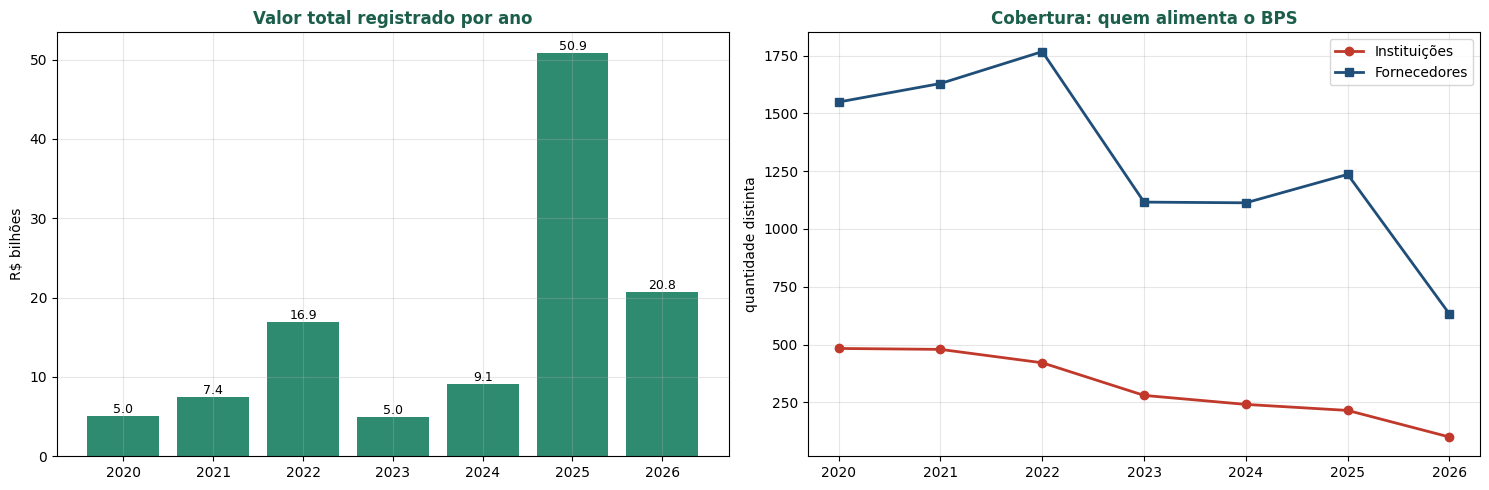

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(anual.index.astype(str), anual["valor_bilhoes"], color=VERDE_MEDIO)
ax1.set_title("Valor total registrado por ano", fontweight="bold", color=VERDE_ESCURO)
ax1.set_ylabel("R$ bilhões")
for x, v in zip(anual.index.astype(str), anual["valor_bilhoes"]):
    ax1.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax2.plot(anual.index.astype(str), anual["instituicoes"], marker="o",
         color=VERMELHO, linewidth=2, label="Instituições")
ax2.plot(anual.index.astype(str), anual["fornecedores"], marker="s",
         color=AZUL, linewidth=2, label="Fornecedores")
ax2.set_title("Cobertura: quem alimenta o BPS", fontweight="bold", color=VERDE_ESCURO)
ax2.set_ylabel("quantidade distinta")
ax2.legend()

plt.tight_layout()
plt.show()

Valor crescente e cobertura decrescente: 483 instituições informantes em
2020 contra 215 em 2025. 2026 é ano parcial, com dados até agosto.

## CONCENTRAÇÃO DO VALOR

In [29]:
ordenado = df["vl_preco_total"].sort_values(ascending=False)
total = ordenado.sum()

rel_kpi.p("\n\n4. CONCENTRAÇÃO DO VALOR")
rel_kpi.p("-" * 74)
for n in [10, 100, 1000, 10000]:
    parte = ordenado.head(n).sum()
    rel_kpi.p(f"  Os {numero(n):>6} maiores registros = {parte / total * 100:5.1f}% "
              f"do valor total ({moeda(parte)})")
rel_kpi.p(f"\n  Total de registros na base: {numero(len(df))}")



4. CONCENTRAÇÃO DO VALOR
--------------------------------------------------------------------------
  Os     10 maiores registros =  54.6% do valor total (R$ 62.864.115.976,00)
  Os    100 maiores registros =  67.4% do valor total (R$ 77.525.874.156,40)
  Os  1.000 maiores registros =  82.7% do valor total (R$ 95.176.791.167,70)
  Os 10.000 maiores registros =  94.3% do valor total (R$ 108.486.695.848,18)

  Total de registros na base: 367.365


In [30]:
colunas_maiores = ["nr_ano_compra", "sg_uf", "no_pdm", "un_fornecimento",
                   "qt_itens_comprados", "vl_preco_unitario",
                   "vl_preco_unitario_mediano_item", "vl_indice_preco_vs_mediana",
                   "vl_preco_total"]

maiores = df.nlargest(10, "vl_preco_total")[colunas_maiores].copy()

rel_kpi.p("\n  Dez maiores registros por valor total:")
for i, (_, l) in enumerate(maiores.iterrows(), start=1):
    rel_kpi.p(f"    {i:>2}. {l['nr_ano_compra']} | {l['sg_uf']} | {str(l['no_pdm'])[:26]:<26} | "
              f"unit. {moeda(l['vl_preco_unitario']):>18} | {moeda(l['vl_preco_total']):>20}")
    rel_kpi.p(f"        índice vs mediana do item: {l['vl_indice_preco_vs_mediana']}")

maiores


  Dez maiores registros por valor total:
     1. 2025 | PR | PENICILAMINA               | unit.      R$ 294.400,00 | R$ 22.816.000.000,00
        índice vs mediana do item: 10257.84
     2. 2025 | SP | OCTREOTIDA                 | unit.      R$ 520.000,00 | R$ 14.591.200.000,00
        índice vs mediana do item: 12189.405
     3. 2026 | PR | AMOXICILINA                | unit.       R$ 51.038,16 | R$ 13.351.582.656,00
        índice vs mediana do item: 260398.776
     4. 2025 | SP | ÁCIDO ZOLEDRÔNICO          | unit.      R$ 199.000,00 |  R$ 3.712.743.000,00
        índice vs mediana do item: 902.679
     5. 2026 | RS | INSULINA                   | unit.       R$ 45.715,00 |  R$ 2.889.188.000,00
        índice vs mediana do item: 2208.988
     6. 2024 | RJ | TEZEPELUMABE               | unit.    R$ 8.191.720,00 |  R$ 1.662.919.160,00
        índice vs mediana do item: 1054.48
     7. 2023 | RJ | CARFILZOMIB                | unit.    R$ 4.804.290,00 |  R$ 1.364.418.360,00
        índice

,nr_ano_compra,sg_uf,no_pdm,un_fornecimento,qt_itens_comprados,vl_preco_unitario,vl_preco_unitario_mediano_item,vl_indice_preco_vs_mediana,vl_preco_total
336289,2025,PR,PENICILAMINA,CÁPSULA,77500,294400.00,28.7000,1.025784e+04,2.281600e+10
347603,2025,SP,OCTREOTIDA,AMPOLA,28060,520000.00,42.6600,1.218941e+04,1.459120e+10
362565,2026,PR,AMOXICILINA,CÁPSULA,261600,51038.16,0.1960,2.603988e+05,1.335158e+10
337304,2025,SP,ÁCIDO ZOLEDRÔNICO,BOLSA,18657,199000.00,220.4550,9.026790e+02,3.712743e+09
358853,2026,RS,INSULINA,FRASCO,63200,45715.00,20.6950,2.208988e+03,2.889188e+09
299966,2024,RJ,TEZEPELUMABE,SERINGA,203,8191720.00,7768.4950,1.054480e+03,1.662919e+09
265310,2023,RJ,CARFILZOMIB,FRASCO-AMPOLA,284,4804290.00,4549.5100,1.056002e+03,1.364418e+09
319080,2024,SP,BUDESONIDA,FRASCO,40000,23980.00,22.0000,1.090000e+03,9.592000e+08
359301,2026,RS,CARBONATO DE CÁLCIO,COMPRIMIDO,699,1149000.00,0.0800,1.436250e+07,8.031510e+08
298546,2024,RJ,AXITINIBE,COMPRIMIDO,2820,253090.00,273.4761,9.254560e+02,7.137138e+08


Dez registros, de 367 mil, já respondem por 54,6% do valor da base. Os preços
unitários envolvidos não fazem o menor sentido: amoxicilina a R$ 51.038 por
comprimido (260.399× a mediana do item), carbonato de cálcio a R$ 1.149.000.

E mesmo assim são internamente consistentes, preço × quantidade bate com o
total certinho. A distorção só aparece quando comparo com a mediana do
próprio item.

## DISPERSÃO DE PREÇOS

In [31]:
faixas = df.groupby("ds_faixa_alerta_preco").agg(
    registros=("cd_seq_bps", "size"),
    valor_total=("vl_preco_total", "sum"),
).sort_index()
faixas["%_registros"] = (faixas["registros"] / len(df) * 100).round(2)
faixas["%_valor"] = (faixas["valor_total"] / df["vl_preco_total"].sum() * 100).round(1)
faixas["valor_bilhoes"] = (faixas["valor_total"] / 1e9).round(2)

rel_kpi.p("\n\n5. DISPERSÃO DE PREÇOS - OPORTUNIDADES DE INVESTIGAÇÃO")
rel_kpi.p("-" * 74)
rel_kpi.p("\n  Diferença de preço não comprova sobrepreço nem irregularidade.\n")
for faixa, l in faixas.iterrows():
    rel_kpi.p(f"    {faixa:<26}{numero(l['registros']):>9} registros "
              f"({l['%_registros']:5.2f}%)   {l['%_valor']:5.1f}% do valor")

faixas[["registros", "%_registros", "valor_bilhoes", "%_valor"]]



5. DISPERSÃO DE PREÇOS - OPORTUNIDADES DE INVESTIGAÇÃO
--------------------------------------------------------------------------

  Diferença de preço não comprova sobrepreço nem irregularidade.

    1 - Muito acima (>=5x)       10.000 registros ( 2.72%)    57.7% do valor
    2 - Acima (2x a 5x)          27.737 registros ( 7.55%)     1.6% do valor
    3 - Faixa esperada          296.013 registros (80.58%)    35.9% do valor
    4 - Abaixo (<=0,5x)          19.101 registros ( 5.20%)     3.8% do valor
    5 - Sem comparacao           14.514 registros ( 3.95%)     1.1% do valor


,registros,%_registros,valor_bilhoes,%_valor
ds_faixa_alerta_preco,,,,
1 - Muito acima (>=5x),10000,2.72,66.34,57.7
2 - Acima (2x a 5x),27737,7.55,1.83,1.6
3 - Faixa esperada,296013,80.58,41.30,35.9
"4 - Abaixo (<=0,5x)",19101,5.20,4.33,3.8
5 - Sem comparacao,14514,3.95,1.27,1.1


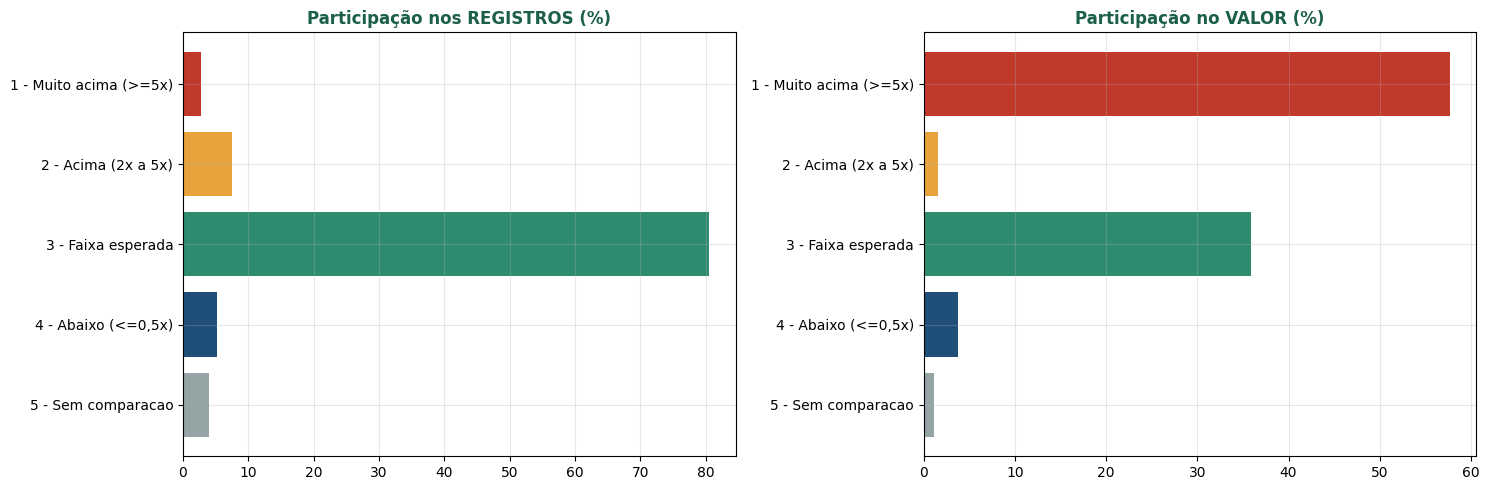

In [32]:
cores = [VERMELHO, AMBAR, VERDE_MEDIO, AZUL, "#95A5A6"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.barh(faixas.index, faixas["%_registros"], color=cores)
ax1.set_title("Participação nos REGISTROS (%)", fontweight="bold", color=VERDE_ESCURO)
ax1.invert_yaxis()
ax2.barh(faixas.index, faixas["%_valor"], color=cores)
ax2.set_title("Participação no VALOR (%)", fontweight="bold", color=VERDE_ESCURO)
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
# Mínimo de 30 registros comparáveis por item
comparaveis = df[df["vl_preco_unitario_mediano_item"].notna()]

dispersao = comparaveis.groupby(["no_pdm", "un_fornecimento"]).agg(
    registros=("vl_preco_unitario", "size"),
    minimo=("vl_preco_unitario", "min"),
    mediana=("vl_preco_unitario", "median"),
    maximo=("vl_preco_unitario", "max"),
)
dispersao = dispersao[dispersao["registros"] >= 30]
dispersao["razao_max_mediana"] = (dispersao["maximo"] / dispersao["mediana"]).round(0)

rel_kpi.p("\n  Itens com maior dispersão (mín. 30 registros comparáveis):")
for (pdm, unidade), l in dispersao.nlargest(10, "razao_max_mediana").iterrows():
    rel_kpi.p(f"    {str(pdm)[:38]:<38} ({unidade}) - {numero(l['registros'])} registros")
    rel_kpi.p(f"      mín {moeda(l['minimo']):>14} | mediana {moeda(l['mediana']):>14} "
              f"| máx {moeda(l['maximo']):>18}  ({numero(l['razao_max_mediana'])}x)")

dispersao.nlargest(10, "razao_max_mediana")


  Itens com maior dispersão (mín. 30 registros comparáveis):
    CARBONATO DE CÁLCIO                    (COMPRIMIDO) - 937 registros
      mín        R$ 0,00 | mediana        R$ 0,09 | máx    R$ 1.149.000,00  (13.131.429x)
    AMOXICILINA                            (CÁPSULA) - 846 registros
      mín        R$ 0,00 | mediana        R$ 0,20 | máx       R$ 51.038,16  (255.191x)
    PAROXETINA CLORIDRATO                  (COMPRIMIDO) - 760 registros
      mín        R$ 0,11 | mediana        R$ 0,26 | máx        R$ 8.000,00  (30.769x)
    BUDESONIDA                             (CÁPSULA) - 63 registros
      mín        R$ 0,37 | mediana        R$ 0,73 | máx       R$ 20.089,24  (27.516x)
    OXIBUTININA CLORIDRATO                 (COMPRIMIDO) - 265 registros
      mín        R$ 0,22 | mediana        R$ 0,78 | máx       R$ 20.000,00  (25.641x)
    REAGENTE PARA DIAGNÓSTICO CLÍNICO 5    (UNIDADE) - 293 registros
      mín        R$ 0,20 | mediana        R$ 0,80 | máx       R$ 15.900,00  (19.8

,,registros,minimo,mediana,maximo,razao_max_mediana
no_pdm,un_fornecimento,,,,,
CARBONATO DE CÁLCIO,COMPRIMIDO,937,0.0009,0.0875,1149000.00,13131429.0
AMOXICILINA,CÁPSULA,846,0.0017,0.2000,51038.16,255191.0
PAROXETINA CLORIDRATO,COMPRIMIDO,760,0.1100,0.2600,8000.00,30769.0
BUDESONIDA,CÁPSULA,63,0.3733,0.7301,20089.24,27516.0
OXIBUTININA CLORIDRATO,COMPRIMIDO,265,0.2200,0.7800,20000.00,25641.0
REAGENTE PARA DIAGNÓSTICO CLÍNICO 5,UNIDADE,293,0.1999,0.8000,15900.00,19875.0
ESCOPOLAMINA BUTILBROMETO,COMPRIMIDO,852,0.0062,0.4500,5500.00,12222.0
OCTREOTIDA,AMPOLA,41,35.5900,46.8500,520000.00,11099.0
NEBULIZADOR,UNIDADE,44,7.5000,138.1300,1439000.00,10418.0


> As variações podem decorrer de fabricante, apresentação, unidade de
> fornecimento, quantidade adquirida, localidade, modalidade de compra e período
> da negociação. O indicador aponta onde verificar, não o que concluir.

## RANKINGS

In [34]:
def ranking(coluna, metrica="vl_preco_total", n=10):
    serie = df.groupby(coluna)[metrica].sum().nlargest(n)
    return pd.DataFrame({"valor": serie,
                         "%_do_total": (serie / df[metrica].sum() * 100).round(1)})


rel_kpi.p("\n\n6. RANKINGS")
rel_kpi.p("-" * 74)
for coluna, titulo in [("sg_uf", "UF"), ("no_municipio", "Municípios"),
                       ("no_instituicao", "Instituições compradoras"),
                       ("no_fornecedor", "Fornecedores"),
                       ("no_fabricante", "Fabricantes"), ("no_pdm", "Itens")]:
    rel_kpi.p(f"\n  Top 10 {titulo} por valor total")
    for i, (nome, l) in enumerate(ranking(coluna).iterrows(), start=1):
        rel_kpi.p(f"    {i:>2}. {str(nome)[:50]:<52}{moeda(l['valor']):>22}{l['%_do_total']:>7.1f}%")

ranking("sg_uf")



6. RANKINGS
--------------------------------------------------------------------------

  Top 10 UF por valor total
     1. PR                                                    R$ 42.938.927.332,87   37.3%
     2. SP                                                    R$ 42.745.917.684,73   37.1%
     3. RS                                                     R$ 6.208.871.088,95    5.4%
     4. CE                                                     R$ 5.396.969.234,82    4.7%
     5. RJ                                                     R$ 5.303.513.275,51    4.6%
     6. SC                                                     R$ 1.940.847.107,01    1.7%
     7. AL                                                     R$ 1.784.490.741,15    1.6%
     8. BA                                                     R$ 1.565.931.261,07    1.4%
     9. ES                                                     R$ 1.366.598.954,81    1.2%
    10. PB                                                     

,valor,%_do_total
sg_uf,,
PR,4.293893e+10,37.3
SP,4.274592e+10,37.1
RS,6.208871e+09,5.4
CE,5.396969e+09,4.7
RJ,5.303513e+09,4.6
SC,1.940847e+09,1.7
AL,1.784491e+09,1.6
BA,1.565931e+09,1.4
ES,1.366599e+09,1.2


In [35]:
sem_alerta = df[df["ds_faixa_alerta_preco"] != "1 - Muito acima (>=5x)"]

comparativo = pd.DataFrame({
    "com_tudo_bi": df.groupby("sg_uf")["vl_preco_total"].sum() / 1e9,
    "sem_faixa1_bi": sem_alerta.groupby("sg_uf")["vl_preco_total"].sum() / 1e9,
})
comparativo["queda_%"] = (
    (1 - comparativo["sem_faixa1_bi"] / comparativo["com_tudo_bi"]) * 100).round(1)

rel_kpi.p("\n\n7. EFEITO DOS REGISTROS SUSPEITOS NO RANKING DE UF")
rel_kpi.p("-" * 74)
rel_kpi.p("\n" + comparativo.nlargest(6, "com_tudo_bi").round(2).to_string())

comparativo.nlargest(8, "com_tudo_bi").round(2)



7. EFEITO DOS REGISTROS SUSPEITOS NO RANKING DE UF
--------------------------------------------------------------------------

       com_tudo_bi  sem_faixa1_bi  queda_%
sg_uf                                     
PR           42.94           5.95     86.1
SP           42.75          22.46     47.5
RS            6.21           2.42     61.0
CE            5.40           5.38      0.3
RJ            5.30           1.45     72.6
SC            1.94           1.89      2.8


,com_tudo_bi,sem_faixa1_bi,queda_%
sg_uf,,,
PR,42.94,5.95,86.1
SP,42.75,22.46,47.5
RS,6.21,2.42,61.0
CE,5.40,5.38,0.3
RJ,5.30,1.45,72.6
SC,1.94,1.89,2.8
AL,1.78,1.25,29.7
BA,1.57,1.55,1.1


Excluindo a faixa "muito acima", o Paraná perde 86% do valor e São Paulo
assume a liderança. Já o Ceará quase não muda, o que é um bom sinal pra base
de preços do estado.

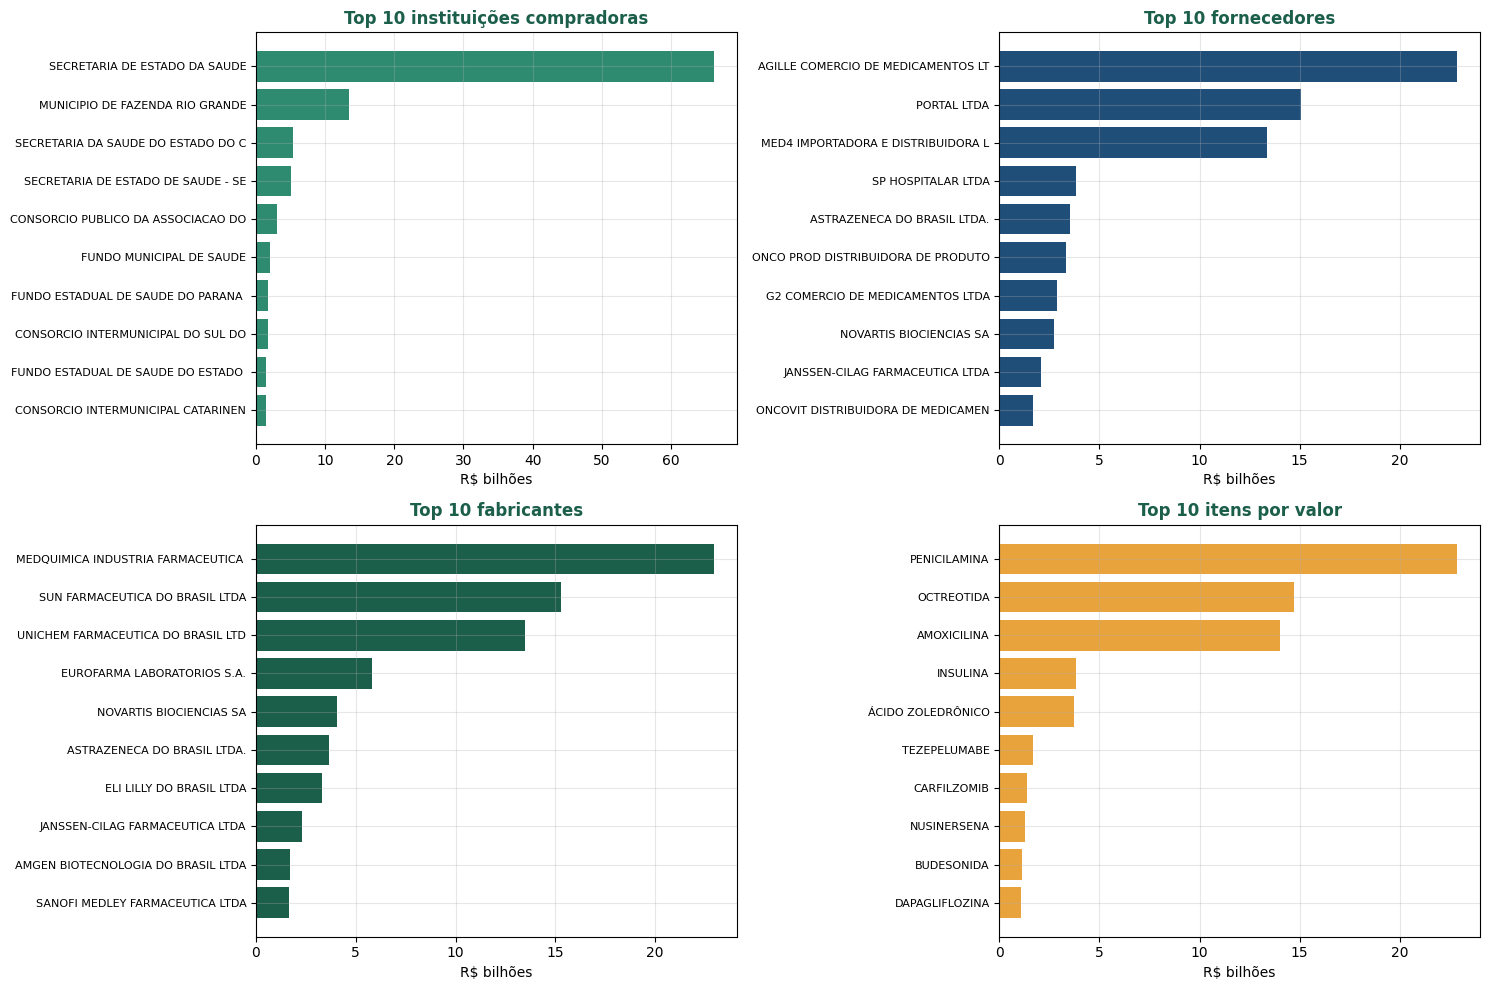

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

blocos = [
    ("no_instituicao", "Top 10 instituições compradoras", VERDE_MEDIO, axes[0][0]),
    ("no_fornecedor", "Top 10 fornecedores", AZUL, axes[0][1]),
    ("no_fabricante", "Top 10 fabricantes", VERDE_ESCURO, axes[1][0]),
    ("no_pdm", "Top 10 itens por valor", AMBAR, axes[1][1]),
]

for coluna, titulo, cor, ax in blocos:
    serie = df.groupby(coluna)["vl_preco_total"].sum().nlargest(10) / 1e9
    ax.barh([str(i)[:34] for i in serie.index], serie.values, color=cor)
    ax.invert_yaxis()
    ax.set_title(titulo, fontweight="bold", color=VERDE_ESCURO)
    ax.set_xlabel("R$ bilhões")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## VALOR X QUANTIDADE

In [37]:
por_valor = df.groupby("no_pdm")["vl_preco_total"].sum().nlargest(10)
por_quantidade = df.groupby("no_pdm")["qt_itens_comprados"].sum().nlargest(10)

lado_a_lado = pd.DataFrame({
    "top por VALOR": por_valor.index,
    "R$ bilhões": (por_valor.values / 1e9).round(2),
    "top por QUANTIDADE": por_quantidade.index,
    "bilhões de unidades": (por_quantidade.values / 1e9).round(2),
}, index=range(1, 11))

em_comum = set(por_valor.index) & set(por_quantidade.index)
rel_kpi.p(f"\n\n8. VALOR x QUANTIDADE - itens nas duas listas: {len(em_comum)}")

print(f"Itens presentes nas duas listas: {len(em_comum)}\n")
lado_a_lado



8. VALOR x QUANTIDADE - itens nas duas listas: 0
Itens presentes nas duas listas: 0



,top por VALOR,R$ bilhões,top por QUANTIDADE,bilhões de unidades
1,PENICILAMINA,22.86,DIETA ENTERAL,7.46
2,OCTREOTIDA,14.73,AMITRIPTILINA CLORIDRATO,3.24
3,AMOXICILINA,14.01,LOSARTANA POTÁSSICA,2.24
4,INSULINA,3.81,HIDROCLOROTIAZIDA,1.85
5,ÁCIDO ZOLEDRÔNICO,3.74,METFORMINA CLORIDRATO,1.69
6,TEZEPELUMABE,1.67,OMEPRAZOL,1.58
7,CARFILZOMIB,1.38,DIPIRONA SÓDICA,1.55
8,NUSINERSENA,1.27,GABAPENTINA,1.48
9,BUDESONIDA,1.15,SINVASTATINA,1.41
10,DAPAGLIFLOZINA,1.09,ANLODIPINO BESILATO,1.38


As listas não têm nada em comum. O ranking por quantidade (dieta enteral,
amitriptilina, losartana, hidroclorotiazida, metformina) acompanha o perfil
epidemiológico brasileiro e, por ser quantidade, não sofre com os erros de
preço que aparecem no outro ranking.

## PERFIL DAS COMPRAS

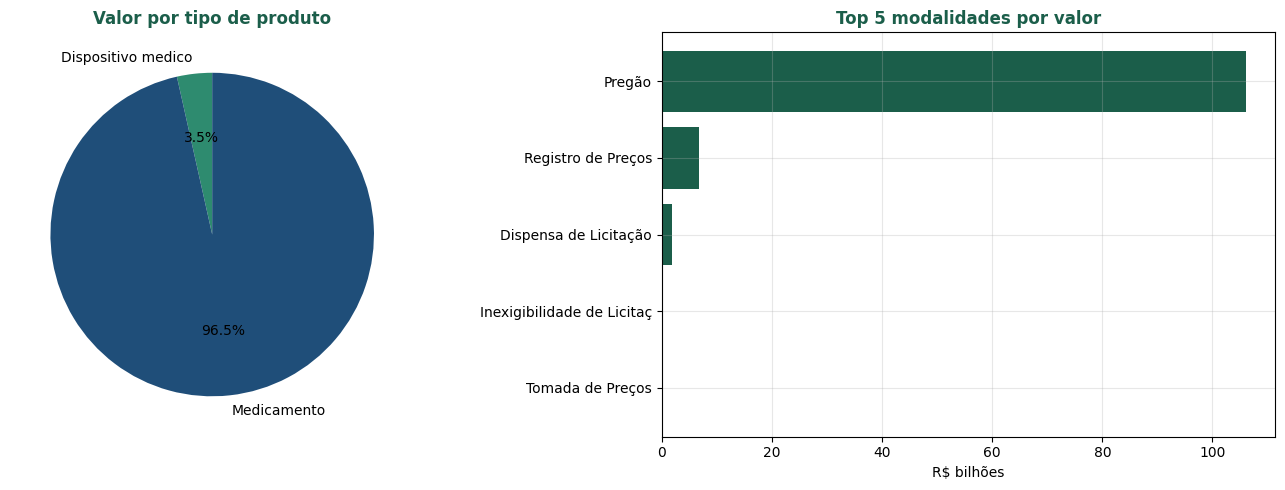

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tipo = df.groupby("ds_tipo_produto")["vl_preco_total"].sum()
ax1.pie(tipo.values, labels=tipo.index, autopct="%1.1f%%",
        colors=[VERDE_MEDIO, AZUL], startangle=90)
ax1.set_title("Valor por tipo de produto", fontweight="bold", color=VERDE_ESCURO)

modalidade = df.groupby("ds_modalidade_compra")["vl_preco_total"].sum().nlargest(5) / 1e9
ax2.barh([str(i)[:26] for i in modalidade.index], modalidade.values, color=VERDE_ESCURO)
ax2.invert_yaxis()
ax2.set_title("Top 5 modalidades por valor", fontweight="bold", color=VERDE_ESCURO)
ax2.set_xlabel("R$ bilhões")

plt.tight_layout()
plt.show()

In [39]:
rel_kpi.p("\n\n9. PERFIL DAS COMPRAS")
rel_kpi.p("-" * 74)

for coluna in ["ds_esfera", "tp_compra", "ds_tipo_produto", "fg_generico",
               "ds_modalidade_compra"]:
    resumo = df.groupby(coluna).agg(
        registros=("cd_seq_bps", "size"),
        valor=("vl_preco_total", "sum"),
    ).sort_values("valor", ascending=False)
    rel_kpi.p(f"\n  {coluna}")
    for nome, l in resumo.head(6).iterrows():
        rel_kpi.p(f"    {str(nome)[:34]:<36}{moeda(l['valor']):>22}"
                  f"{l['valor'] / resumo['valor'].sum() * 100:>7.1f}%"
                  f"{numero(l['registros']):>12} registros")

df.groupby("ds_tipo_produto").agg(
    registros=("cd_seq_bps", "size"),
    valor_bi=("vl_preco_total", lambda s: round(s.sum() / 1e9, 2)),
)



9. PERFIL DAS COMPRAS
--------------------------------------------------------------------------

  ds_esfera
    ESTADUAL                              R$ 86.123.392.979,52   74.8%      27.816 registros
    MUNICIPAL                             R$ 28.936.412.098,31   25.1%     339.384 registros
    FEDERAL                                    R$ 5.250.886,51    0.0%         122 registros
    PRIVADA                                       R$ 77.131,51    0.0%          43 registros

  tp_compra
    ADMINISTRATIVA                       R$ 107.572.071.744,02   93.5%     361.364 registros
    JUDICIAL                               R$ 7.493.061.351,83    6.5%       6.001 registros

  ds_tipo_produto
    Medicamento                          R$ 111.033.385.187,53   96.5%     290.775 registros
    Dispositivo medico                     R$ 4.031.747.908,32    3.5%      76.590 registros

  fg_generico
    Nao generico                          R$ 74.599.663.298,64   64.8%      83.483 registros
    

,registros,valor_bi
ds_tipo_produto,,
Dispositivo medico,76590,4.03
Medicamento,290775,111.03


## COBERTURA GEOGRÁFICA

In [40]:
UFS_BRASIL = set("AC AL AP AM BA CE DF ES GO MA MT MS MG PA PB PR PE PI "
                 "RJ RN RS RO RR SC SP SE TO".split())
presentes = set(df["sg_uf"].dropna().unique())

rel_kpi.p("\n\n10. COBERTURA GEOGRÁFICA")
rel_kpi.p("-" * 74)
rel_kpi.p(f"  UFs com registro: {len(presentes)} de 27")
rel_kpi.p(f"  UFs ausentes ...: {sorted(UFS_BRASIL - presentes)}")
rel_kpi.p("  Alimentação voluntária: ausência indica não informação, não ausência de compra.")

print(f"UFs com registro: {len(presentes)} de 27")
print(f"Ausentes: {sorted(UFS_BRASIL - presentes)}")

df.groupby("sg_uf").agg(
    valor_bi=("vl_preco_total", lambda s: round(s.sum() / 1e9, 2)),
    registros=("cd_seq_bps", "size"),
    instituicoes=("cnpj_instituicao", "nunique"),
    municipios=("no_municipio", "nunique"),
).sort_values("valor_bi", ascending=False)



10. COBERTURA GEOGRÁFICA
--------------------------------------------------------------------------
  UFs com registro: 24 de 27
  UFs ausentes ...: ['AM', 'AP', 'DF']
  Alimentação voluntária: ausência indica não informação, não ausência de compra.
UFs com registro: 24 de 27
Ausentes: ['AM', 'AP', 'DF']


,valor_bi,registros,instituicoes,municipios
sg_uf,,,,
PR,42.94,78925,175,149
SP,42.75,64571,114,107
RS,6.21,23917,52,49
CE,5.40,5127,11,10
RJ,5.30,8177,23,19
SC,1.94,11503,15,11
AL,1.78,12359,34,30
BA,1.57,2640,10,9
ES,1.37,10194,34,31


In [41]:
rel_kpi.salvar(DIR_RELATORIOS / "relatorio_kpis.txt")


>>> relatorio_kpis.txt


# CONCLUSÕES

1. **Concentração extrema.** Dez registros, de 367 mil, respondem por 54,6% do
   valor da base.

2. **A concentração vem de preço, não de volume.** Os maiores registros têm preço
   unitário de centenas a milhões de vezes a mediana do próprio item.

3. **Erro de plausibilidade, não aritmético.** Preço × quantidade bate em 100% da
   base. A validação ausente no BPS é de ordem de grandeza.

4. **Os rankings dependem do filtro de alerta.** Excluída a faixa "muito acima", o
   Paraná perde 86% do valor e São Paulo assume a liderança.

5. **Cobertura decrescente.** De 483 instituições informantes em 2020 para 215 em
   2025; AM, AP e DF nunca aparecem.

6. **Resultados estáveis.** Medicamentos representam 96,5% do valor, o pregão
   92,2%, e o ranking por quantidade acompanha o perfil epidemiológico brasileiro.

---

## Saídas

| Arquivo | Conteúdo |
|---------|----------|
| `dados/raw/<ANO>.csv` | Sete bases anuais originais |
| `dados/staging/BPS_<ANO>_tratado.csv` | Cada ano padronizado e limpo |
| `dados/curated/BPS_20_26_AnaysaPereiraLopes.csv` | Base consolidada |
| `dados/curated/BPS_20_26_AnaysaPereiraLopes.csv.gz` | Versão compactada, para o BigQuery |
| `relatorios/relatorio_discrepancias.txt` | Diagnóstico da Sprint 1 |
| `relatorios/relatorio_tratamento.txt` | Log do tratamento e da concatenação |
| `relatorios/relatorio_kpis.txt` | KPIs, validação e rankings |

Análise completa, recomendações e limitações no `README.md`.